# Linear Algebra

Importing Libraries

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

## 1. Vectors

A vector is a quantity that has both **magnitude and direction**. This characteristic distinguishes vectors from **scalars**, which only have magnitude.

* **Magnitude** refers to the **size or numerical value** of a quantity.
* **Direction** indicates the **orientation or the way in which the quantity acts**.

Graphically, vectors are usually represented by **arrows**. The **length of the arrow** indicates the **magnitude of the vector**, while the **arrowhead shows its direction**.


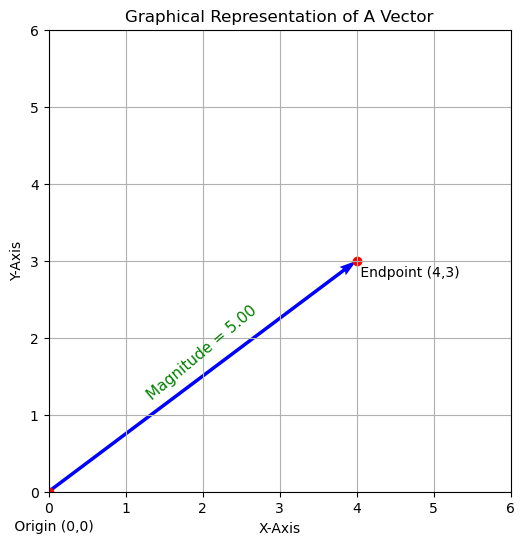

In [2]:
# Example Vector (4,3)
x, y = 4, 3   

# Magnitude
magnitude = np.sqrt(x**2 + y**2)

fig, ax = plt.subplots(figsize=(6,6))

# Draw Vector Arrow
ax.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1, color='blue')

# Mark Origin And Endpoint
ax.scatter([0, x], [0, y], color='red')

# Annotate Origin
ax.text(-0.5, -0.5, ' Origin (0,0)', fontsize=10)

# Annotate Endpoint
ax.text(x, y - 0.2, f' Endpoint ({x},{y})', fontsize=10)

# Annotate Magnitude
ax.text(x/2, (y/2) - 0.3, f'Magnitude = {magnitude:.2f}', 
        fontsize=11, color='green', ha='center', rotation=40)


# Axis Formatting
ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.set_aspect('equal')
ax.set_xlabel('X-Axis')
ax.set_ylabel('Y-Axis')
ax.set_title('Graphical Representation of A Vector')

# Grid
ax.grid(True)

plt.show()

### 1.1 Vector Notation

There are different ways to represent vectors. Some of the most common methods are given below.

1. **Using a letter with an arrow above it:** A vector can be written as a letter with an arrow above it, such as $\vec{u}$, $\vec{v}$, or $\vec{a}$.

2. **Using bold letters:** Vectors can also be represented by bold letters, such as $\textbf{u}$, $\textbf{v}$, or $\textbf{a}$.

3. **Using directed line segment notation:** A vector can be represented as a directed line segment between two points. For example, if a vector starts at point $A$ and ends at point $B$, it is written as $\vec{AB}$.

4. **Using component notation (in coordinate geometry):** In coordinate geometry, vectors are often represented using component notation. A vector in two-dimensional space can be written as $\begin{bmatrix} x \ y \end{bmatrix}$, while a vector in three-dimensional space can be written as $\begin{bmatrix} x \ y \ z \end{bmatrix}$. These components show how much the vector moves along each coordinate axis.

### 1.2 Vector Operations

Vector Operations are mathematcial processes used to combine or manipulate vectors

Two of the main operations are:
- Vector Addition
- Scalar Multiplication

### Vector Addition

Vector addition is used to combine two or more vectors to obtain a **resultant vector**. When vectors are added, both their **magnitudes and directions** are taken into account.

**Algebraically**, vectors can be added by adding their corresponding components.

**Example:**

$$
\vec{u} = \begin{bmatrix}1 \\ 5\end{bmatrix},
\quad
\vec{v} = \begin{bmatrix}5 \\ 10\end{bmatrix}
$$

$$
\vec{u} + \vec{v} =
\begin{bmatrix}1 + 5 \\ 5 + 10\end{bmatrix}

\begin{bmatrix}6 \\ 15\end{bmatrix}
$$

**Graphically**, vector addition can be performed using the **triangle law of vector addition**.


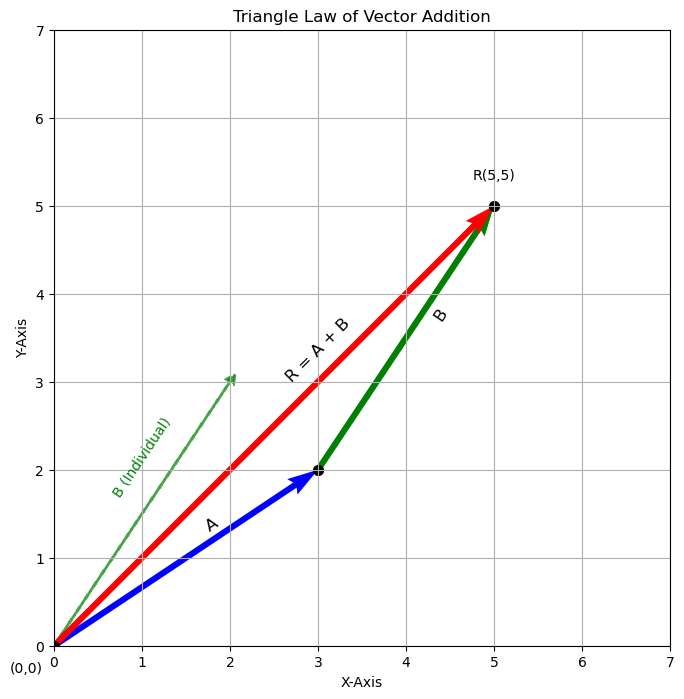

In [3]:
A = np.array([3, 2])
B = np.array([2, 3])
R = A + B

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title("Triangle Law of Vector Addition")
ax.set_xlabel('X-Axis')
ax.set_ylabel('Y-Axis')
ax.set_aspect('equal')
ax.grid()

def animate(i):
    ax.clear()
    ax.set_xlim(0, 7)
    ax.set_ylim(0, 7)
    ax.grid()
    ax.set_title("Triangle Law of Vector Addition")
    ax.set_xlabel('X-Axis')
    ax.set_ylabel('Y-Axis')
    ax.set_aspect('equal')
    
    artists = []
    
    if i >= 1:
        # Draw Vector A
        qA = ax.quiver(0, 0, A[0], A[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.01)
        angle_A = np.degrees(np.arctan2(A[1], A[0]))
        tA = ax.text(A[0]/2 + 0.3, A[1]/2 + 0.3, "A", fontsize=12, ha='center', rotation=angle_A)
        artists.extend([qA, tA])
    
    if i >= 2:
        # Draw Vector B Individually (From Origin) With Dashed Line
        arrB = ax.arrow(0, 0, B[0], B[1], head_width=0.1, head_length=0.1, fc='green', ec='green', linestyle='--', alpha=0.7, linewidth=2)
        angle_B = np.degrees(np.arctan2(B[1], B[0]))
        tB_ind = ax.text(B[0]/2, B[1]/2 + 0.2, "B (Individual)", fontsize=10, color='green', ha='center', rotation=angle_B)
        artists.extend([arrB, tB_ind])
    
    if i >= 3:
        # Draw Vector B Starting From A
        qB_tri = ax.quiver(A[0], A[1], B[0], B[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.01)
        tB_tri = ax.text(A[0] + B[0]/2 + 0.4, A[1] + B[1]/2 + 0.2, "B", fontsize=12, ha='center', rotation=angle_B)
        artists.extend([qB_tri, tB_tri])
    
    if i >= 4:
        # Draw Resultant Vector R
        qR = ax.quiver(0, 0, R[0], R[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)
        angle_R = np.degrees(np.arctan2(R[1], R[0]))
        tR = ax.text(R[0]/2 + 0.5, R[1]/2 + 0.5, "R = A + B", fontsize=12, ha='center', rotation=angle_R)
        artists.extend([qR, tR])
        
        # Mark Points
        scat = ax.scatter([0, A[0], A[0]+B[0]], [0, A[1], A[1]+B[1]], color='black', s=50)
        t0 = ax.text(0-0.5, 0-0.3, '(0,0)', fontsize=10)
        tR_pt = ax.text(A[0]+B[0], A[1]+B[1]+0.3, f'R({R[0]},{R[1]})', fontsize=10, ha='center')
        artists.extend([scat, t0, tR_pt])
    
    return artists

ani = FuncAnimation(fig, animate, frames=5, interval=1500, blit=True)

HTML(ani.to_jshtml())

Another graphical method of vector addition is the **parallelogram law**. In this method, the two vectors are drawn as adjacent sides of a parallelogram. The **diagonal of the parallelogram** then represents the **resultant vector**.

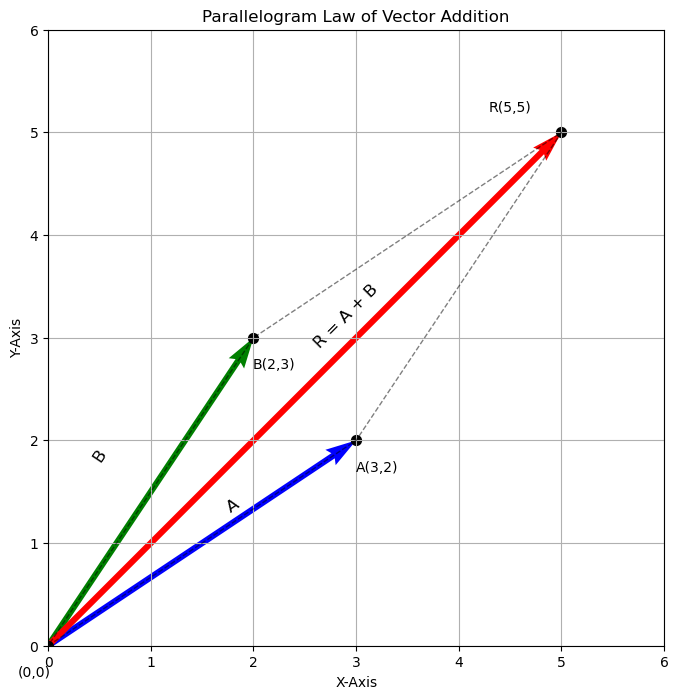

In [4]:
A = np.array([3, 2])
B = np.array([2, 3])
R = A + B

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title("Parallelogram Law of Vector Addition")
ax.set_xlabel('X-Axis')
ax.set_ylabel('Y-Axis')
ax.set_aspect('equal')
ax.grid()

def animate(i):
    ax.clear()
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 6)
    ax.grid()
    ax.set_title("Parallelogram Law of Vector Addition")
    ax.set_xlabel('X-Axis')
    ax.set_ylabel('Y-Axis')
    ax.set_aspect('equal')
    
    artists = []
    
    if i >= 1:
        # Draw Vector A From Origin
        angle_A = np.degrees(np.arctan2(A[1], A[0]))
        qA = ax.quiver(0, 0, A[0], A[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.01)
        tA = ax.text(A[0]/2 + 0.3, A[1]/2 + 0.3, "A", fontsize=12, ha='center', rotation=angle_A)
        artists.extend([qA, tA])
    
    if i >= 2:
        # Draw Vector B From Origin
        angle_B = np.degrees(np.arctan2(B[1], B[0]))
        qB = ax.quiver(0, 0, B[0], B[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.01)
        tB = ax.text(B[0]/2 - 0.5, B[1]/2 + 0.3, "B", fontsize=12, ha='center', rotation=angle_B)
        artists.extend([qB, tB])
    
    if i >= 3:
        # Draw Resultant Vector R (Diagonal)
        angle_R = np.degrees(np.arctan2(R[1], R[0]))
        qR = ax.quiver(0, 0, R[0], R[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)
        tR = ax.text(R[0]/2 + 0.4, R[1]/2 + 0.4, "R = A + B", fontsize=12, ha='center', rotation=angle_R)
        artists.extend([qR, tR])
    
    if i >= 4:
        # Draw Parallelogram Outline
        para = ax.plot([0, A[0], R[0], B[0], 0], [0, A[1], R[1], B[1], 0], 'k--', alpha=0.5, linewidth=1)[0]
        
        # Mark Points
        scat = ax.scatter([0, A[0], B[0], R[0]], [0, A[1], B[1], R[1]], color='black', s=50)
        t0 = ax.text(0-0.3, 0-0.3, '(0,0)', fontsize=10)
        tA_pt = ax.text(A[0] + 0.2, A[1] - 0.3, f'A({A[0]},{A[1]})', fontsize=10, ha='center')
        tB_pt = ax.text(B[0] + 0.2, B[1] - 0.3, f'B({B[0]},{B[1]})', fontsize=10, ha='center')
        tR_pt = ax.text(R[0] - 0.5, R[1] + 0.2, f'R({R[0]},{R[1]})', fontsize=10, ha='center')
        artists.extend([para, scat, t0, tA_pt, tB_pt, tR_pt])
    
    return artists

ani = FuncAnimation(fig, animate, frames=5, interval=1500, blit=True)

HTML(ani.to_jshtml())

### Scalar Multiplication

Scalar multiplication is another fundamental vector operation. In this operation, a vector is multiplied by a scalar (a real number). The result of scalar multiplication is a new vector whose magnitude is multiplied by the scalar value, while its direction either remains the same or reverses depending on the sign of the scalar.

If the scalar is positive, the direction of the vector remains unchanged. If the scalar is negative, the direction of the vector reverses.

Algebrically, A Vector Scalar Multiplication Can Also Be Represented By Multiplying The Vector By A Scalar

**Example:** 
$$
\vec{u} = \begin{bmatrix}5 \\ 10\end{bmatrix} \rightarrow 2 \cdot \vec{u} 
= 
\begin{bmatrix}2 \cdot 5 \\ 2 \cdot 10\end{bmatrix} 
= 
\begin{bmatrix}10 \\ 20\end{bmatrix}
$$

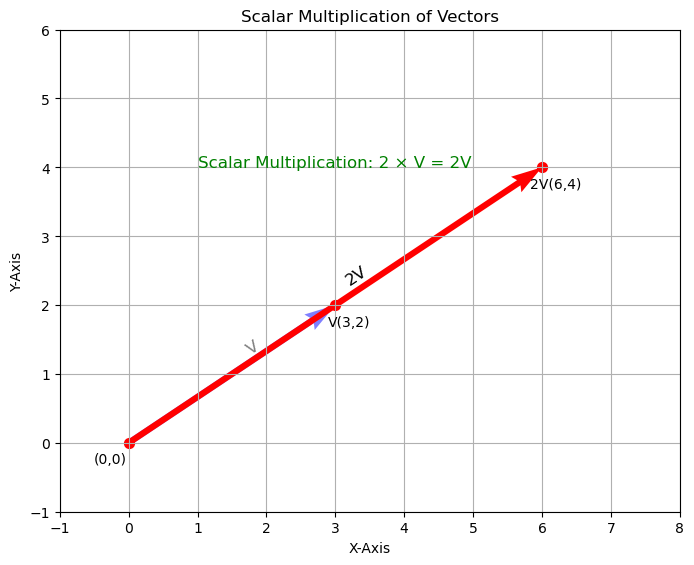

In [5]:
V = np.array([3, 2])
k = 2
scaled = k * V

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title("Scalar Multiplication of Vectors")
ax.set_xlabel('X-Axis')
ax.set_ylabel('Y-Axis')
ax.set_aspect('equal')
ax.grid()

def animate(i):
    ax.clear()
    ax.set_xlim(-1, 8)
    ax.set_ylim(-1, 6)
    ax.grid()
    ax.set_title("Scalar Multiplication of Vectors")
    ax.set_xlabel('X-Axis')
    ax.set_ylabel('Y-Axis')
    ax.set_aspect('equal')
    
    artists = []
    
    if i == 0:
        # Show Original Vector V
        qV = ax.quiver(0, 0, V[0], V[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.01)
        angle_V = np.degrees(np.arctan2(V[1], V[0]))
        tV = ax.text(V[0]/2 + 0.3, V[1]/2 + 0.3, "V", fontsize=12, ha='center', rotation=angle_V)
        # Annotate Co-ordinates
        ax.scatter([0, V[0]], [0, V[1]], color='red', s=50)
        t0 = ax.text(0-0.5, 0-0.3, '(0,0)', fontsize=10)
        tV_pt = ax.text(V[0]+0.2, V[1]-0.3, f'V({V[0]},{V[1]})', fontsize=10, ha='center')
        artists.extend([qV, tV, t0, tV_pt])
    
    elif i < 9:
        # Scaling Animation
        scale_factor = 1 + (k - 1) * (i - 1) / 8  # Gradually scale from 1 to k
        current_scaled = scale_factor * V
        q_scaled = ax.quiver(0, 0, current_scaled[0], current_scaled[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)
        angle_scaled = np.degrees(np.arctan2(current_scaled[1], current_scaled[0]))
        t_scaled = ax.text(current_scaled[0]/2 + 0.3, current_scaled[1]/2 + 0.3, f"{scale_factor:.1f}V", fontsize=12, ha='center', rotation=angle_scaled)
        # Annotate Scalar
        ax.text(1, 4, f'Scaling by: {scale_factor:.1f}', fontsize=12, color='green')
        artists.extend([q_scaled, t_scaled])
    
    else:
        # Final Frame: Show Both Original And Scaled Vectors
        # Original Vector (Faded)
        qV_orig = ax.quiver(0, 0, V[0], V[1], angles='xy', scale_units='xy', scale=1, color='blue', alpha=0.5, width=0.01)
        angle_V = np.degrees(np.arctan2(V[1], V[0]))
        tV_orig = ax.text(V[0]/2 + 0.3, V[1]/2 + 0.3, "V", fontsize=12, ha='center', rotation=angle_V, alpha=0.5)
        
        # Scaled Vector
        q_scaled = ax.quiver(0, 0, scaled[0], scaled[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)
        angle_scaled = np.degrees(np.arctan2(scaled[1], scaled[0]))
        t_scaled = ax.text(scaled[0]/2 + 0.3, scaled[1]/2 + 0.3, f"{k}V", fontsize=12, ha='center', rotation=angle_scaled)
        
        # Annotate Coordinates
        ax.scatter([0, V[0], scaled[0]], [0, V[1], scaled[1]], color='red', s=50)
        t0 = ax.text(0-0.5, 0-0.3, '(0,0)', fontsize=10)
        tV_pt = ax.text(V[0]+0.2, V[1]-0.3, f'V({V[0]},{V[1]})', fontsize=10, ha='center')
        t_scaled_pt = ax.text(scaled[0]+0.2, scaled[1]-0.3, f'{k}V({scaled[0]},{scaled[1]})', fontsize=10, ha='center')
        
        # Annotate Scalar
        ax.text(1, 4, f'Scalar Multiplication: {k} × V = {k}V', fontsize=12, color='green')
        
        artists.extend([qV_orig, tV_orig, q_scaled, t_scaled, t0, tV_pt, t_scaled_pt])
    
    return artists

ani = FuncAnimation(fig, animate, frames=10, interval=800, blit=True)

HTML(ani.to_jshtml())

## Vector Spaces

A **vector space** is a collection of objects called *vectors* that can be **added together** and **multiplied by scalars (numbers)**, in a way that satisfies certain **axioms**. These axioms ensure that the operations behave **consistently and predictably.**

Vector spaces are **highly general** and are not limited to geometric arrows. They can also include **functions, polynomials, matrices, sequences**, and many other mathematical objects.

Because vectors can be added and scaled, we can form expressions by combining them. Such expressions are called **linear combinations**. 

For example, if $\vec{v}_1, \vec{v}_2, \cdots, \vec{v}_n$ are vectors and $c_1, c_2, \cdots, c_n$ are scalars, then
$$
c_1 \vec{v}_1 + c_2 \vec{v}_2 + \cdots + c_n \vec{v}_n
$$

is a linear combination of those vectors

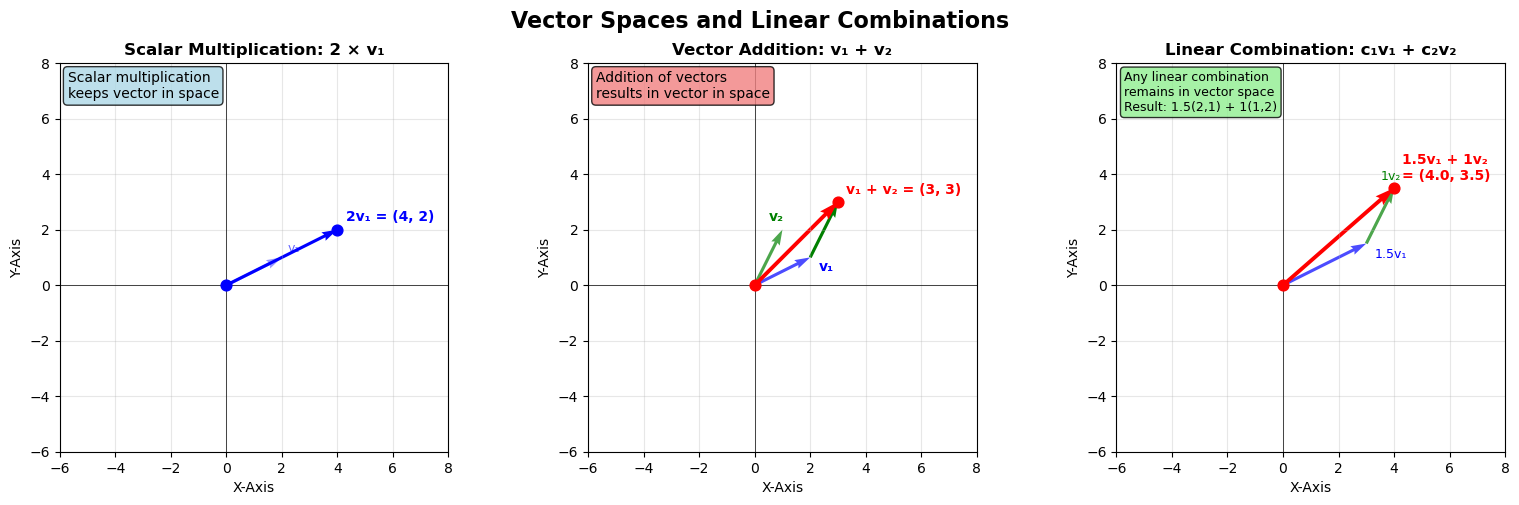

In [ ]:
v1 = np.array([2, 1])  # First Basis Vector
v2 = np.array([1, 2])  # Second Basis Vector

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Vector Spaces and Linear Combinations', fontsize=16, fontweight='bold')

def animate_vector_space(i):
    # Clear All Axes
    for ax in axes.flat:
        ax.clear()
        ax.set_xlim(-6, 8)
        ax.set_ylim(-6, 8)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        ax.axhline(y=0, color='k', linewidth=0.5)
        ax.axvline(x=0, color='k', linewidth=0.5)
    
    artists = []
    
    # Scalar Multiplication
    ax1 = axes[0]
    ax1.set_title('Scalar Multiplication: 2 × v₁', fontsize=12, fontweight='bold')
    ax1.set_xlabel('X-Axis')
    ax1.set_ylabel('Y-Axis')
    
    if i >= 0:
        # Draw v1 (Faded)
        q1_orig = ax1.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, 
                            color='blue', alpha=0.4, width=0.008)
        t1_orig = ax1.text(v1[0]+0.2, v1[1]+0.2, 'v₁', fontsize=9, color='blue', alpha=0.6)
        artists.extend([q1_orig, t1_orig])
    
    if i >= 1:
        # Draw 2*v1
        scaled_v1 = 2 * v1
        q1_scaled = ax1.quiver(0, 0, scaled_v1[0], scaled_v1[1], angles='xy', scale_units='xy', scale=1, 
                              color='blue', width=0.008)
        t1_scaled = ax1.text(scaled_v1[0]+0.3, scaled_v1[1]+0.3, '2v₁ = (4, 2)', fontsize=10, 
                           color='blue', fontweight='bold')
        ax1.scatter([0, scaled_v1[0]], [0, scaled_v1[1]], color='blue', s=60, zorder=5)
        artists.extend([q1_scaled, t1_scaled])
        
        # Add Explanation
        info_text = "Scalar Multiplication\nKeeps Vector In Space"
        ax1.text(0.02, 0.98, info_text, transform=ax1.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Vector Addition
    ax2 = axes[1]
    ax2.set_title('Vector Addition: v₁ + v₂', fontsize=12, fontweight='bold')
    ax2.set_xlabel('X-Axis')
    ax2.set_ylabel('Y-Axis')
    
    if i >= 2:
        # Draw v1
        q1 = ax2.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, 
                        color='blue', width=0.008, alpha=0.7)
        t1 = ax2.text(v1[0]+0.3, v1[1]-0.5, 'v₁', fontsize=10, color='blue', fontweight='bold')
        artists.extend([q1, t1])
    
    if i >= 3:
        # Draw v2 From Origin
        q2 = ax2.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, 
                        color='green', width=0.008, alpha=0.7)
        t2 = ax2.text(v2[0]-0.5, v2[1]+0.3, 'v₂', fontsize=10, color='green', fontweight='bold')
        artists.extend([q2, t2])
    
    if i >= 4:
        # Draw v2 From Tip of v1 (Triangle Law)
        q2_from_v1 = ax2.quiver(v1[0], v1[1], v2[0], v2[1], angles='xy', scale_units='xy', scale=1, 
                               color='green', width=0.008)
        artists.append(q2_from_v1)
    
    if i >= 5:
        # Draw Resultant
        result = v1 + v2
        q_result = ax2.quiver(0, 0, result[0], result[1], angles='xy', scale_units='xy', scale=1, 
                            color='red', width=0.01)
        t_result = ax2.text(result[0]+0.3, result[1]+0.3, f'v₁ + v₂ = ({result[0]}, {result[1]})', 
                          fontsize=10, color='red', fontweight='bold')
        ax2.scatter([0, result[0]], [0, result[1]], color='red', s=60, zorder=5)
        artists.extend([q_result, t_result])
        
        # Add Explanation
        info_text = "Addition of vectors\nresults in vector in space"
        ax2.text(0.02, 0.98, info_text, transform=ax2.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))
    
    # Linear Combination
    ax3 = axes[2]
    ax3.set_title('Linear Combination: c₁v₁ + c₂v₂', fontsize=12, fontweight='bold')
    ax3.set_xlabel('X-Axis')
    ax3.set_ylabel('Y-Axis')
    
    if i >= 6:
        c1, c2 = 1.5, 1
        
        # Draw Scale v1
        scaled_v1 = c1 * v1
        q1_scaled = ax3.quiver(0, 0, scaled_v1[0], scaled_v1[1], angles='xy', scale_units='xy', scale=1, 
                              color='blue', width=0.008, alpha=0.7)
        t1_scaled = ax3.text(scaled_v1[0]+0.3, scaled_v1[1]-0.5, f'{c1}v₁', fontsize=9, color='blue')
        artists.extend([q1_scaled, t1_scaled])
        
        # Draw Scaled v2 From Tip of Scaled v1
        scaled_v2 = c2 * v2
        q2_scaled = ax3.quiver(scaled_v1[0], scaled_v1[1], scaled_v2[0], scaled_v2[1], 
                              angles='xy', scale_units='xy', scale=1, color='green', width=0.008, alpha=0.7)
        t2_scaled = ax3.text(scaled_v1[0]+scaled_v2[0]-0.5, scaled_v1[1]+scaled_v2[1]+0.3, f'{c2}v₂', 
                           fontsize=9, color='green')
        artists.extend([q2_scaled, t2_scaled])
    
    if i >= 7:
        c1, c2 = 1.5, 1
        scaled_v1 = c1 * v1
        scaled_v2 = c2 * v2
        linear_combo = scaled_v1 + scaled_v2
        
        # Draw Resultant Linear Combination
        q_combo = ax3.quiver(0, 0, linear_combo[0], linear_combo[1], angles='xy', scale_units='xy', scale=1, 
                            color='red', width=0.01)
        t_combo = ax3.text(linear_combo[0]+0.3, linear_combo[1]+0.3, 
                          f'{c1}v₁ + {c2}v₂\n= ({linear_combo[0]:.1f}, {linear_combo[1]:.1f})', 
                          fontsize=10, color='red', fontweight='bold')
        ax3.scatter([0, linear_combo[0]], [0, linear_combo[1]], color='red', s=60, zorder=5)
        artists.extend([q_combo, t_combo])
        
        # Add explanation
        info_text = (f"Any linear combination\nremains in vector space\n"
                    f"Result: {c1}(2,1) + {c2}(1,2)")
        ax3.text(0.02, 0.98, info_text, transform=ax3.transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    return artists

ani = FuncAnimation(fig, animate_vector_space, frames=8, interval=1200, blit=True)
plt.tight_layout()
HTML(ani.to_jshtml())

Similarly, we have **subspaces**, which are essentially “smaller vector spaces” contained within a larger **vector space**.

More formally, if $V$ is a **vector space**, a set $W \subseteq V$ is called a **subspace** if it is itself a **vector space** under the same operations of **addition** and **scalar multiplication** defined in $V$

The **span** of a set of **vectors** is the collection of all possible **linear combinations** of those vectors.

In other words, if you have vectors $\vec{v}_1, \vec{v}_2, \ldots, \vec{v}_n$, the **span** is the **smallest subspace** that contains all these vectors. It represents all the points you can “reach” by **scaling** and **adding** these vectors together.

If a set of vectors **spans** a **vector space**, every vector in that space can be written as a **linear combination** of the **spanning set**.


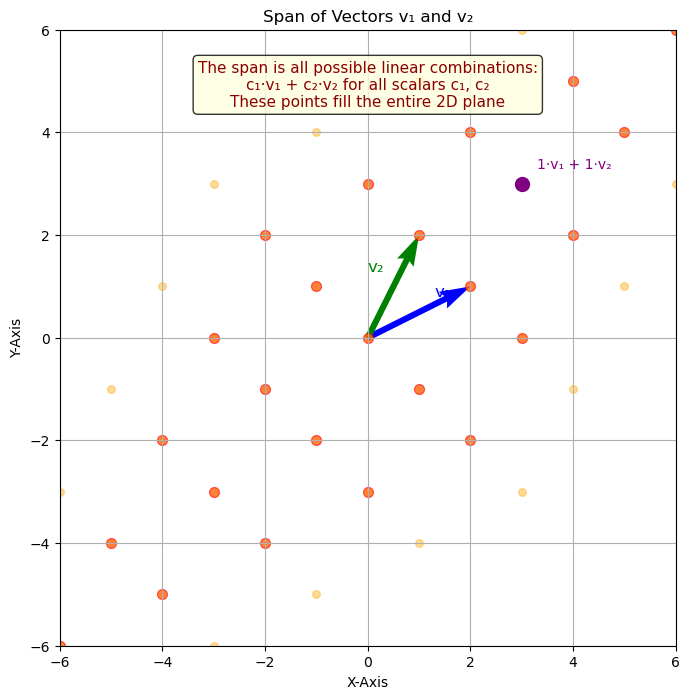

In [6]:
v1 = np.array([2, 1])
v2 = np.array([1, 2])

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title("Span of Vectors v₁ and v₂")
ax.set_xlabel('X-Axis')
ax.set_ylabel('Y-Axis')
ax.set_aspect('equal')
ax.grid(True)

def animate_span(i):
    ax.clear()
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.grid(True)
    ax.set_title("Span of Vectors v₁ and v₂")
    ax.set_xlabel('X-Axis')
    ax.set_ylabel('Y-Axis')
    ax.set_aspect('equal')
    
    artists = []
    
    # Always Show The Basis Vectors
    q1 = ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.01)
    t1 = ax.text(v1[0]/2 + 0.3, v1[1]/2 + 0.3, "v₁", fontsize=12, color='blue')
    q2 = ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.01)
    t2 = ax.text(v2[0]/2 - 0.5, v2[1]/2 + 0.3, "v₂", fontsize=12, color='green')
    artists.extend([q1, t1, q2, t2])
    
    if i >= 1:
        # Show Some Linear Combinations As Points
        coeffs = np.linspace(-2, 2, 5)
        points = []
        for c1 in coeffs:
            for c2 in coeffs:
                point = c1 * v1 + c2 * v2
                points.append(point)
        points = np.array(points)
        scat = ax.scatter(points[:,0], points[:,1], color='red', alpha=0.6, s=50)
        artists.append(scat)
        
        # Annotate One Point
        example_point = 1*v1 + 1*v2
        ax.scatter(example_point[0], example_point[1], color='purple', s=100, zorder=5)
        ax.text(example_point[0] + 0.3, example_point[1] + 0.3, "1·v₁ + 1·v₂", fontsize=10, color='purple')
    
    if i >= 2:
        # Add More Points For Denser Span
        coeffs2 = np.linspace(-3, 3, 7)
        points2 = []
        for c1 in coeffs2:
            for c2 in coeffs2:
                point = c1 * v1 + c2 * v2
                points2.append(point)
        points2 = np.array(points2)
        scat2 = ax.scatter(points2[:,0], points2[:,1], color='orange', alpha=0.4, s=30)
        artists.append(scat2)
    
    if i >= 3:
        # Explain The Concept
        ax.text(0, 4.5, "The span is all possible linear combinations:\n"
                "c₁·v₁ + c₂·v₂ for all scalars c₁, c₂\n"
                "These points fill the entire 2D plane", 
                fontsize=11, ha='center', color='darkred', 
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    return artists

ani = FuncAnimation(fig, animate_span, frames=4, interval=1500, blit=True)

HTML(ani.to_jshtml())